In [ ]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from dotenv import load_dotenv
import matplotlib.pyplot as plt

from api_client import TradingDeskAPI
from scanner import MarketScannerFast

In [ ]:
# Initialize all classes and parameters

load_dotenv(r"D:/OneDrive/Trading/Prediction Markets/Moreton Capital/.env")
# load_dotenv(r"C:/Users/brian/OneDrive/Trading/Prediction Markets/Moreton Capital/.env")
BASE_URL = os.getenv("BASE_URL")
USER_EMAIL = os.getenv("USER_EMAIL")
USER_PASSWORD = os.getenv("USER_PASSWORD")
JWT_TOKEN = os.getenv("JWT")
DATA_DIR = os.getenv("DATA_DIR")
print(BASE_URL)

api = TradingDeskAPI(base_url=BASE_URL, email=USER_EMAIL, password=USER_PASSWORD, token=JWT_TOKEN)
scanner = MarketScannerFast(api=api)

https://alphasignal-dev.moretoncp.com


In [3]:
# 9. Get current markets
all_markets_df = api.get_all_markets(DATA_DIR=DATA_DIR, count_limit=30, liquidity_num_min=10000, volume_num_min=5000)
all_markets_df.head()

Fetched 100 markets | Total: 100
Fetched 100 markets | Total: 200
Fetched 100 markets | Total: 300
Fetched 100 markets | Total: 400
Fetched 100 markets | Total: 500
Fetched 100 markets | Total: 600
Fetched 100 markets | Total: 700
Fetched 100 markets | Total: 800
Fetched 100 markets | Total: 900
Fetched 100 markets | Total: 1,000
Fetched 100 markets | Total: 1,100
Fetched 100 markets | Total: 1,200
Fetched 100 markets | Total: 1,300
Fetched 100 markets | Total: 1,400
Fetched 100 markets | Total: 1,500
Fetched 100 markets | Total: 1,600
Fetched 100 markets | Total: 1,700
Fetched 100 markets | Total: 1,800
Fetched 100 markets | Total: 1,900
Fetched 100 markets | Total: 2,000
Fetched 100 markets | Total: 2,100
Fetched 100 markets | Total: 2,200
Fetched 100 markets | Total: 2,300
Fetched 100 markets | Total: 2,400
Fetched 100 markets | Total: 2,500
Fetched 100 markets | Total: 2,600
Fetched 100 markets | Total: 2,700
Fetched 100 markets | Total: 2,800
Fetched 100 markets | Total: 2,900
Fet

,id,question,conditionId,slug,resolutionSource,endDate,liquidity,startDate,image,icon,...,showGmpOutcome,umaResolutionStatus,oneHourPriceChange,eventStartTime,gameStartTime,groupItemRange,secondsDelay,sportsMarketType,line,marketMetadata
0,559651,Xi Jinping out before 2027?,0xa467b14d51f01b957109d9cbb1d6c124fab2a089d52e...,xi-jinping-out-before-2027,,2026-12-31T00:00:00Z,193190.05922,2025-07-03T20:37:00.228Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,559652,Will Gavin Newsom win the 2028 Democratic pres...,0x0f49db97f71c68b1e42a6d16e3de93d85dbf7d4148e3...,will-gavin-newsom-win-the-2028-democratic-pres...,,2028-11-07T00:00:00Z,367292.38378,2025-07-11T18:35:56.805Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,559653,Will Alexandria Ocasio-Cortez win the 2028 Dem...,0xe6bcc2f1dd025ce5e1833190f7c60a71171c94f805df...,will-alexandria-ocasio-cortez-win-the-2028-dem...,,2028-11-07T00:00:00Z,373771.32926,2025-07-11T18:35:59.075Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,559654,Will Pete Buttigieg win the 2028 Democratic pr...,0x4c325469d9b516ef4e6b8f73a81a12607dec075e3c2f...,will-pete-buttigieg-win-the-2028-democratic-pr...,,2028-11-07T00:00:00Z,558886.66268,2025-07-11T18:35:58.818Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,559655,Will Josh Shapiro win the 2028 Democratic pres...,0xd65891729ce093cc12236856837eba1a0872fc7998fd...,will-josh-shapiro-win-the-2028-democratic-pres...,,2028-11-07T00:00:00Z,508091.22644,2025-07-11T18:36:01.098Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
markets_df = scanner.scan_market(all_markets_df)
markets_df

,id,question,conditionId,slug,resolutionSource,endDate,liquidity,startDate,image,icon,...,marketMetadata,tokens,yes_token,no_token,yes_price,no_price,yes_bid_est,yes_ask_est,no_bid_est,no_ask_est
0,559651,Xi Jinping out before 2027?,0xa467b14d51f01b957109d9cbb1d6c124fab2a089d52e...,xi-jinping-out-before-2027,,2026-12-31 00:00:00+00:00,193190.05922,2025-07-03T20:37:00.228Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[323382201900713514357728017797253022445757752...,3233822019007135143577280177972530224457577521...,2565931067499367556234575966511475989240002624...,0.0425,0.9575,0.042,0.043,0.957,0.958
1,559652,Will Gavin Newsom win the 2028 Democratic pres...,0x0f49db97f71c68b1e42a6d16e3de93d85dbf7d4148e3...,will-gavin-newsom-win-the-2028-democratic-pres...,,2028-11-07 00:00:00+00:00,367292.38378,2025-07-11T18:35:56.805Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[545330438199465925475175111769409999556338601...,5453304381994659254751751117694099995563386012...,8785417414807465206046792108118140235746730372...,0.1465,0.8535,0.146,0.147,0.853,0.854
2,559653,Will Alexandria Ocasio-Cortez win the 2028 Dem...,0xe6bcc2f1dd025ce5e1833190f7c60a71171c94f805df...,will-alexandria-ocasio-cortez-win-the-2028-dem...,,2028-11-07 00:00:00+00:00,373771.32926,2025-07-11T18:35:59.075Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[107064985435494333113391038470401719113272800...,1070649854354943331133910384704017191132728005...,6517607226132473785608568807162711850954929392...,0.2095,0.7905,0.209,0.210,0.790,0.791
3,559654,Will Pete Buttigieg win the 2028 Democratic pr...,0x4c325469d9b516ef4e6b8f73a81a12607dec075e3c2f...,will-pete-buttigieg-win-the-2028-democratic-pr...,,2028-11-07 00:00:00+00:00,558886.66268,2025-07-11T18:35:58.818Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[910312791719819591973617101272135771025768265...,9103127917198195919736171012721357710257682651...,1849406552792407375021723776578438036543031939...,0.0525,0.9475,0.052,0.053,0.947,0.948
4,559655,Will Josh Shapiro win the 2028 Democratic pres...,0xd65891729ce093cc12236856837eba1a0872fc7998fd...,will-josh-shapiro-win-the-2028-democratic-pres...,,2028-11-07 00:00:00+00:00,508091.22644,2025-07-11T18:36:01.098Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[711698394974205962858418475141235898478934157...,7116983949742059628584184751412358984789341575...,5529082759955328024596317572494049675355772243...,0.0505,0.9495,0.050,0.051,0.949,0.950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2487206,Next Mythos-Class Model released by September ...,0x0ca328688c590d82b80ec763d0a34353b9b9bd56dd20...,next-mythos-class-model-released-by-september-...,,2026-09-30 03:59:00+00:00,10232.6532,2026-06-10T15:12:01.955Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,None,[874647514465095853783905124367441573143150793...,8746475144650958537839051243674415731431507935...,1094806035104303652577438323970587020896569471...,0.9200,0.0800,0.910,0.930,0.070,0.090
2996,2487274,Another critical Cloudflare incident by August...,0x5856328392136a28db888aa672f6d16cc12d7728c004...,another-critical-cloudflare-incident-by-august...,,2026-09-01 03:59:00+00:00,11910.63277,2026-06-11T13:52:13.202942Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,None,[106558919554284263511666341283706816209398247...,1065589195542842635116663412837068162093982472...,6904194240417753362081467591080279927027085353...,0.0995,0.9005,0.079,0.120,0.880,0.921
2997,2487478,Will Daniel Vilela win the Governor of Goiás e...,0x34e779bcb09867f7a5e1a90f69e469dd18bc8e8050a5..

In [46]:
eth_spot = pd.read_parquet("eth_spot_historical_price.parquet")
eth_spot

,timestamp,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2025-10-01 00:00:00+00:00,4145.15,4151.41,4144.65,4151.41,1038.4316,1759277099999999,4.308127e+06,17178,723.1062,2.999765e+06,0
1,2025-10-01 00:05:00+00:00,4151.41,4152.37,4148.33,4149.14,620.0314,1759277399999999,2.573722e+06,9562,324.4493,1.346717e+06,0
2,2025-10-01 00:10:00+00:00,4149.14,4149.25,4144.35,4145.84,670.3296,1759277699999999,2.779812e+06,7880,262.0305,1.086663e+06,0
3,2025-10-01 00:15:00+00:00,4145.85,4147.04,4140.17,4144.72,719.1728,1759277999999999,2.979700e+06,13383,251.3857,1.041454e+06,0
4,2025-10-01 00:20:00+00:00,4144.72,4145.35,4136.04,4137.47,1241.2362,1759278299999999,5.136679e+06,13317,294.1102,1.216943e+06,0
...,...,...,...,...,...,...,...,...,...,...,...,...
87547,2026-07-31 23:35:00+00:00,1864.16,1864.18,1863.34,1863.92,116.3118,1785541199999999,2.167966e+05,2097,63.0753,1.175620e+05,0
87548,2026-07-31 23:40:00+00:00,1863.91,1864.12,1863.27,1863.61,114.0950,1785541499999999,2.126254e+05,2092,75.2980,1.403189e+05,0
87549,2026-07-31 23:45:00+00:00,1863.61,1863.74,1862.19,1862.19,225.3369,1785541799999999,4.197900e+05,3389,82.7456,1.541642e+05,0
87550,2026-07-31 23:50:00+00:00,1862.20,1863.28,1860.95,1861.76,365.4604,1785542099999999,6.806170e+05,5815,104.5064,1.946097e+05,0


In [ ]:
df = pd.read_parquet("crypto_contracts_price_history_df.parquet")

# Make sure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Pick one market index
market_index = 587

# Filter to that index
df_index = df[df["market_index"] == market_index].copy()

# Sort chronologically
df_index = df_index.sort_values("timestamp")

merged = pd.merge_asof(
    df_index,
    eth_spot.sort_values("timestamp"),
    on="timestamp",
    direction="backward",
    tolerance=pd.Timedelta("5min")
)

merged = merged[merged["Open"] > 0]

merged["eth_return_10m"] = (
    np.log(merged["Close"])
    .diff(2)
)

merged["eth_return_20m"] = (
    np.log(merged["Close"])
    .diff(4)
)

merged["eth_return_30m"] = (
    np.log(merged["Close"])
    .diff(6)
)

intervals = [10, 20, 30, 60, 120, 180, 1440]

for minutes in intervals:
    steps = minutes // 10
    print(steps)

    merged[f"yes_future_{minutes}m"] = (
        merged["price"].shift(-steps)
    )

    merged[f"yes_change_{minutes}m"] = (
        merged[f"yes_future_{minutes}m"] - merged["price"]
    )
merged

1
2
3
6
12
18
144


,timestamp,price,market_index,question,token_id,Open,High,Low,Close,Volume,...,yes_future_30m,yes_change_30m,yes_future_60m,yes_change_60m,yes_future_120m,yes_change_120m,yes_future_180m,yes_change_180m,yes_future_1440m,yes_change_1440m
0,2025-11-24 19:50:19+00:00,0.445,587,"Will Ethereum dip to $1,500 by December 31, 2026?",1016397517895495897653501170727405100188095947...,2958.64,2965.48,2956.81,2957.74,1177.4771,...,0.445,0.0,0.445,0.0,0.45,0.005,0.450,0.005,0.495,0.05
1,2025-11-24 20:00:07+00:00,0.445,587,"Will Ethereum dip to $1,500 by December 31, 2026?",1016397517895495897653501170727405100188095947...,2959.00,2965.60,2954.22,2956.53,1393.1693,...,0.445,0.0,0.445,0.0,0.45,0.005,0.455,0.010,0.495,0.05
2,2025-11-24 20:10:06+00:00,0.445,587,"Will Ethereum dip to $1,500 by December 31, 2026?",1016397517895495897653501170727405100188095947...,2968.26,2987.00,2967.17,2976.22,4601.1598,...,0.445,0.0,0.445,0.0,0.45,0.005,0.455,0.010,0.495,0.05
3,2025-11-24 20:20:06+00:00,0.445,587,"Will Ethereum dip to $1,500 by December 31, 2026?",1016397517895495897653501170727405100188095947...,2979.19,2982.44,2975.62,2976.86,1282.7656,...,0.445,0.0,0.445,0.0,0.45,0.005,0.450,0.005,0.495,0.05
4,2025-11-24 20:30:07+00:00,0.445,587,"Will Ethereum dip to $1,500 by December 31, 2026?",1016397517895495897653501170727405100188095947...,2978.51,2978.77,2970.84,2974.50,1058.2884,...,0.445,0.0,0.445,0.0,0.45,0.005,0.450,0.005,0.495,0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34994,2026-07-31 23:10:10+00:00,0.486,587,"Will Ethereum dip to $1,500 by December 31, 2026?",1016397517895495897653501170727405100188095947...,1862.99,1863.58,1862.39,1862.45,292.9915,...,0.486,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34995,2026-07-31 23:20:14+00:00,0.486,587,"Will Ethereum dip to $1,500 by December 31, 2026?",1016397517895495897653501170727405100188095947...,1863.68,1864.65,1863.30,1863.50,276.7017,...,0.486,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34996,2026-07-31 23:30:12+00:00,0.486,587,"Will Ethereum dip to $1,500 by December 31, 2026?",1016397517895495897653501170727405100188095947...,1864.05,1864.77,1863.55,1864.17,111.8501,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34997,2026-07-31 23:40:11+00:00,0.486,587,"Will Ethereum dip to $1,500 by December 31, 2026?",1016397517895495897653501170727405100188095947...,1863.91,1864.12,1863.27,1863.61,114.0950,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
models = {}

for horizon in [10, 20, 30, 60, 120, 180, 1440]:
    test = merged[
        ["eth_return_10m", f"yes_change_{horizon}m"]
    ].dropna()

    X = sm.add_constant(test["eth_return_10m"])
    y = test[f"yes_change_{horizon}m"]

    model = sm.OLS(y, X).fit()
    models[horizon] = model.params.iloc[1]
    
    print(f"\n{horizon}m")
    print(f"beta: {model.params.iloc[1]:.6f}")
    print(f"t-stat: {model.tvalues.iloc[1]:.3f}")
    print(f"p-value: {model.pvalues.iloc[1]:.6f}")
    print(f"R²: {model.rsquared:.4f}")


10m
beta: -0.124579
t-stat: -16.158
p-value: 0.000000
R²: 0.0074

20m
beta: -0.184855
t-stat: -19.725
p-value: 0.000000
R²: 0.0110

30m
beta: -0.229073
t-stat: -21.308
p-value: 0.000000
R²: 0.0128

60m
beta: -0.334624
t-stat: -23.918
p-value: 0.000000
R²: 0.0161

120m
beta: -0.417629
t-stat: -22.966
p-value: 0.000000
R²: 0.0149

180m
beta: -0.515165
t-stat: -23.643
p-value: 0.000000
R²: 0.0157

1440m
beta: -0.829121
t-stat: -14.741
p-value: 0.000000
R²: 0.0062


In [ ]:
def fee(price):
    return 0.07 * price * (1 - price)

def sortino(x, target=0):
    x = pd.Series(x).dropna()

    downside = np.minimum(x - target, 0)

    downside_dev = np.sqrt(
        np.mean(downside ** 2)
    )

    if downside_dev == 0:
        return np.nan

    return (
        x.mean() - target
    ) / downside_dev

spread = 0.01
half_spread = spread / 2

thresholds = [
    0.005,
    0.01,
    0.015,
    0.02,
    0.03,
    0.05,
    0.10,
    0.20
]

results = []

for threshold in thresholds:

    for horizon in [10, 20, 30, 60, 120, 180, 1440]:

        beta = models[horizon]
        
        s = merged.copy()

        # --------------------------------
        # SIGNAL
        # --------------------------------

        s["predicted_yes_change"] = (
            beta * s["eth_return_10m"]
        )

        s["signal"] = 0

        s.loc[
            s["predicted_yes_change"] > threshold,
            "signal"
        ] = 1       # BUY YES

        s.loc[
            s["predicted_yes_change"] < -threshold,
            "signal"
        ] = -1      # BUY NO
    
        # --------------------------------
        # ONLY TRADE SIGNALS
        # --------------------------------
        s = s[s["signal"] != 0].copy()

        s["entry_price"] = np.where(
            s["signal"] == 1,
            s["price"] + half_spread,
            1 - s["price"] + half_spread
        )

        s["exit_price"] = np.where(
            s["signal"] == 1,
            s[f"yes_future_{horizon}m"] - half_spread,
            1 - s[f"yes_future_{horizon}m"] - half_spread
        )

        s["entry_fee"] = fee(s["entry_price"])
        s["exit_fee"] = fee(s["exit_price"])

        # --------------------------------
        # GROSS P&L
        # --------------------------------

        s["gross_pnl"] = (
            s["exit_price"]
            - s["entry_price"]
        )

        # --------------------------------
        # NET P&L
        # --------------------------------

        s["net_pnl"] = (
            s["gross_pnl"]
            - s["entry_fee"]
            - s["exit_fee"]
        )

        # --------------------------------
        # RETURN
        # --------------------------------

        s["return"] = (
            s["net_pnl"]
            / s["entry_price"]
        )

        x = s["return"].dropna()

        results.append({
            "threshold": threshold,
            "horizon": horizon,
            "N": len(x),
            "mean_return": x.mean(),
            "median_return": x.median(),
            "win_rate": (x > 0).mean(),
            "sortino": sortino(x),
            "total_pnl": s["net_pnl"].sum()
        })

results_df = pd.DataFrame(results)
results_df

# Small and moderate shocks exhibit statistically negative subsequent price changes, but the edge is too small to overcome transaction costs. 
# Very large shocks may contain a tradable mean-reversion signal, particularly at longer horizons.

# “I started with the hypothesis that ETH spot movements should lead repricing in related Polymarket contracts. 
# The intuition was that the underlying market should incorporate information faster than a relatively less liquid prediction market, creating a short-lived relative-value opportunity.
# I tested this across different price thresholds and horizons and then evaluated the resulting trades rather than just looking at correlation. 
# The results were disappointing: the larger-sample regions were generally unprofitable, and the positive results tended to occur in very small samples. 
# After incorporating execution considerations, I couldn't find evidence of a stable economically meaningful edge.

# The important thing I learned was that a plausible economic relationship isn't necessarily a tradable signal. 
# I had to distinguish between correlation, statistical predictability, and actual executable PnL.
#  I also found that the contract's nonlinear payoff and dependence on volatility and time-to-expiry made the relationship with spot much less straightforward than I initially assumed.”

# That's a very solid answer.
# And if they push:
# “So what would you do next?”
# That's where you can really impress them.
# I'd say:
# “I'd decompose the problem rather than immediately adding more ML. 
# First I'd estimate the conditional sensitivity of the contract to spot, volatility and time-to-expiry. 
# Then I'd test whether residual repricing after controlling for those variables is predictable. 
# I'd also explicitly model bid-ask, available liquidity and execution latency. 
# If the residual isn't statistically or economically significant out of sample, I'd stop pursuing that hypothesis rather than optimize it further.”


,threshold,horizon,N,mean_return,median_return,win_rate,sortino,total_pnl
0,0.005,10,8,-0.037889,-0.060597,0.250000,-0.509456,-0.134950
1,0.005,20,46,-0.062995,-0.060597,0.108696,-0.749953,-1.205300
2,0.005,30,107,-0.060333,-0.064697,0.121495,-0.703527,-2.852051
3,0.005,60,318,-0.060730,-0.066028,0.097484,-0.684359,-9.065059
4,0.005,120,588,-0.065518,-0.065800,0.093537,-0.673114,-18.149052
5,0.005,180,1021,-0.069146,-0.068600,0.090108,-0.689016,-31.388192
6,0.005,1440,2767,-0.058066,-0.069138,0.214312,-0.410505,-85.570641
7,0.010,10,0,NaN,NaN,NaN,NaN,0.000000
8,0.010,20,1,-0.079004,-0.079004,0.000000,-1.000000,-0.026071
9,0.010,30,4,-0.062098,-0.062361,0.000000,-0.838165,-0.086687


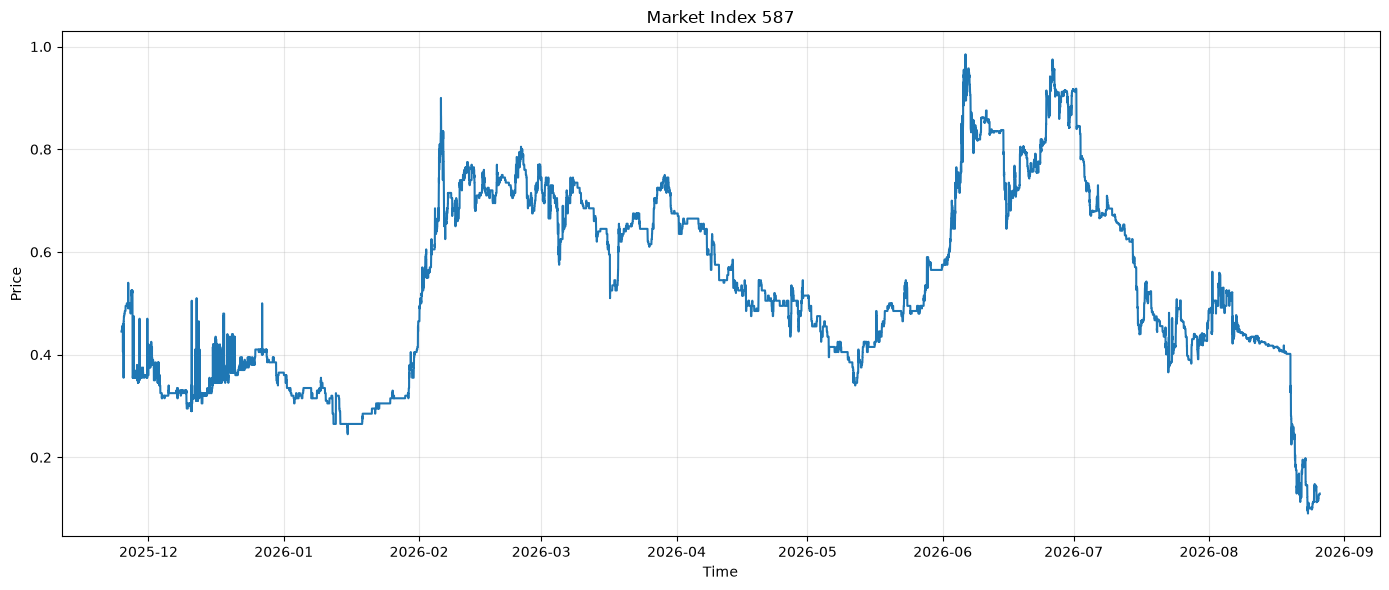

In [ ]:
df = pd.read_parquet("crypto_contracts_price_history_df.parquet")

# Make sure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Pick one market index
market_index = 587

# Filter to that index
df_index = df[df["market_index"] == market_index].copy()

# Sort chronologically
df_index = df_index.sort_values("timestamp")

# Plot price over time
plt.figure(figsize=(14, 6))
plt.plot(df_index["timestamp"], df_index["price"])

plt.xlabel("Time")
plt.ylabel("Price")
plt.title(f"Market Index {market_index}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

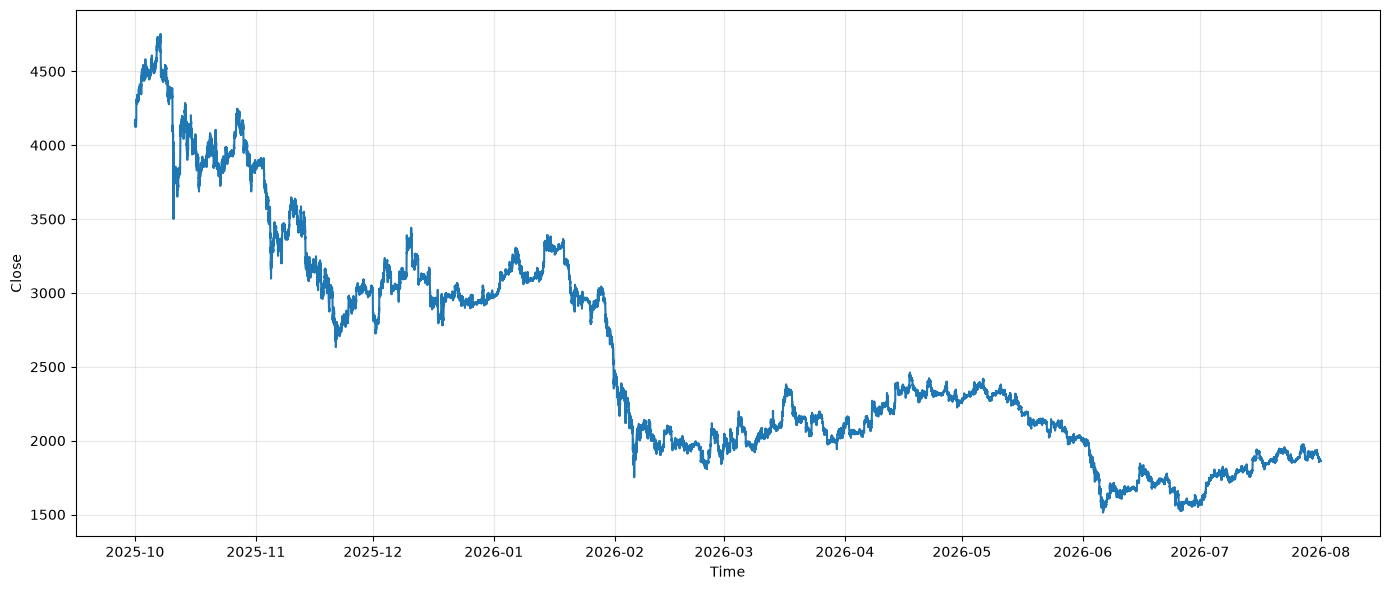

In [ ]:
df = eth_spot

# Make sure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Sort chronologically
df_index = df.sort_values("timestamp")

# Plot price over time
plt.figure(figsize=(14, 6))
plt.plot(df_index["timestamp"], df_index["Close"])

plt.xlabel("Time")
plt.ylabel("Close")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()